# Gruppo 2613
- Giacomo Bregolin 2188429
- Leonardo Fardin 2197525
- Lara Fogarolo 2199475
- Francesco Peron 2185610

# Exercise 4: data visualization and clustering

## 1. "eps" and "minPts" in DBSCAN algorithm for clustering

In [12]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.ticker import NullFormatter
plt.rcParams['font.size'] = 12

# manifold.TSNE
from sklearn import manifold  #, datasets
from time import time

from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score

In [13]:
fname,fnamey="x_12d.dat","y_12d.dat" 
data=np.loadtxt("DATA/"+fname, delimiter='\t') #load data and labels
y=np.loadtxt("DATA/"+fnamey,dtype=int)
N=len(data) #number of data points
D=len(data[0]) #number of features
print("N=",N,"  L=D=",D)
x=data

N= 600   L=D= 12


t-SNE with perplexity=2: 1.4 sec
t-SNE with perplexity=4: 1.5 sec
t-SNE with perplexity=8: 1.4 sec
t-SNE with perplexity=16: 1.5 sec
t-SNE with perplexity=32: 1.6 sec


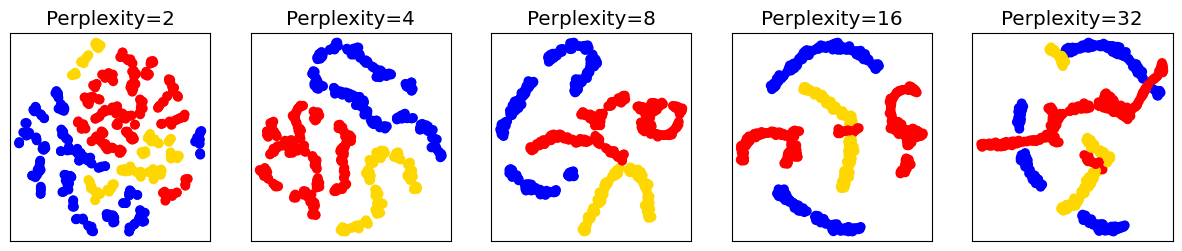

In [14]:
np.random.seed(0)
n_samples = N # number of data points to consider
n_components = 2 # dimension of the embedded space
perplexities = [2, 4, 8, 16, 32]
Np = len(perplexities)
mycmap = ListedColormap(["blue","red","gold" ])

(fig, subplots) = plt.subplots(1,Np , figsize=(3*Np, 2.7))

X_all = [None]
for i, perplexity in enumerate(perplexities):
    ax = subplots[i]

    t0 = time()
    tsne = manifold.TSNE(n_components=n_components, init='random',
                         random_state=0, perplexity=perplexity, learning_rate='auto')
    Y = tsne.fit_transform(data) # apply t-SNE to the data
    t1 = time() # time taken by t-SNE
    print("t-SNE with perplexity=%d: %.2g sec" % (perplexity, t1 - t0))
    ax.set_title("Perplexity=%d" % perplexity)
    ax.scatter(Y[:, 0], Y[:, 1], c=y,cmap=mycmap) # plot the t-SNE embedding
    ax.tick_params(left=False,bottom=False)
    ax.xaxis.set_major_formatter(NullFormatter())
    ax.yaxis.set_major_formatter(NullFormatter())
    ax.axis('tight')
    X_all.append(Y)
    
plt.show()

In [15]:
from kneed import KneeLocator

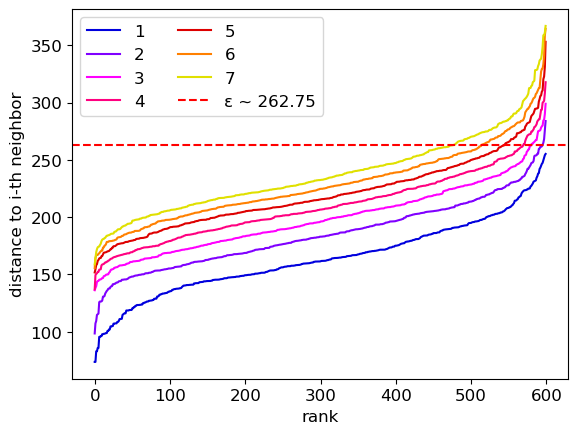

mean minimum distance between nn points:  163.65491354345073


In [16]:
nn = 7
# compute the distance to the nn nearest neighbors
nbrs = NearestNeighbors(n_neighbors=nn+1).fit(x) #, algorithm='ball_tree'
# distances and the indices of the nn nearest neighbors (10+1)
d, ind = nbrs.kneighbors(x) # returns distances and indices of nn neighbors

dd=d.T # distances to the i-th neighbor for all points, sorted by distance

k_distances = np.sort(dd[nn])
cut = int(0.8 * len(k_distances))
k_distances = k_distances[:cut]
l = range(len(k_distances))

knee = KneeLocator(l, k_distances, curve='convex', direction='increasing')
eps_estimate = k_distances[knee.knee]

# note: dd[0] has a trivial set of zeros
listc= ["#0000DD","#8000FF","#FF00FF","#FF0080","#DD0000",
        "#FF8000","#E0E000","#30D000","#00A030","#33A0A0"]
for i in range(1,nn+1):
    plt.plot(np.sort(dd[i]),c=listc[i-1],label=str(i))
    plt.xlabel("rank")
    plt.ylabel("distance to i-th neighbor")
plt.axhline(y=eps_estimate, color='red', linestyle='--', label=f"ε ~ {eps_estimate:.2f}")
plt.legend(ncol=2)
plt.show()
mean_min_dist = np.mean(dd[1]) # mean distance to the nearest neighbor
print("mean minimum distance between nn points: ",mean_min_dist)

The distance value that is larger than 80% of the other distances is used as epsilon for defining clusters. It is not too small and not too large:

If epsilon is too small: there would be too many clusters
If epsilon is too large → clustering becomes imprecise, merging points that are too far apart

This value roughly corresponds to the “knee” of the curve, where the distances start to separate dense neighbors from isolated points.

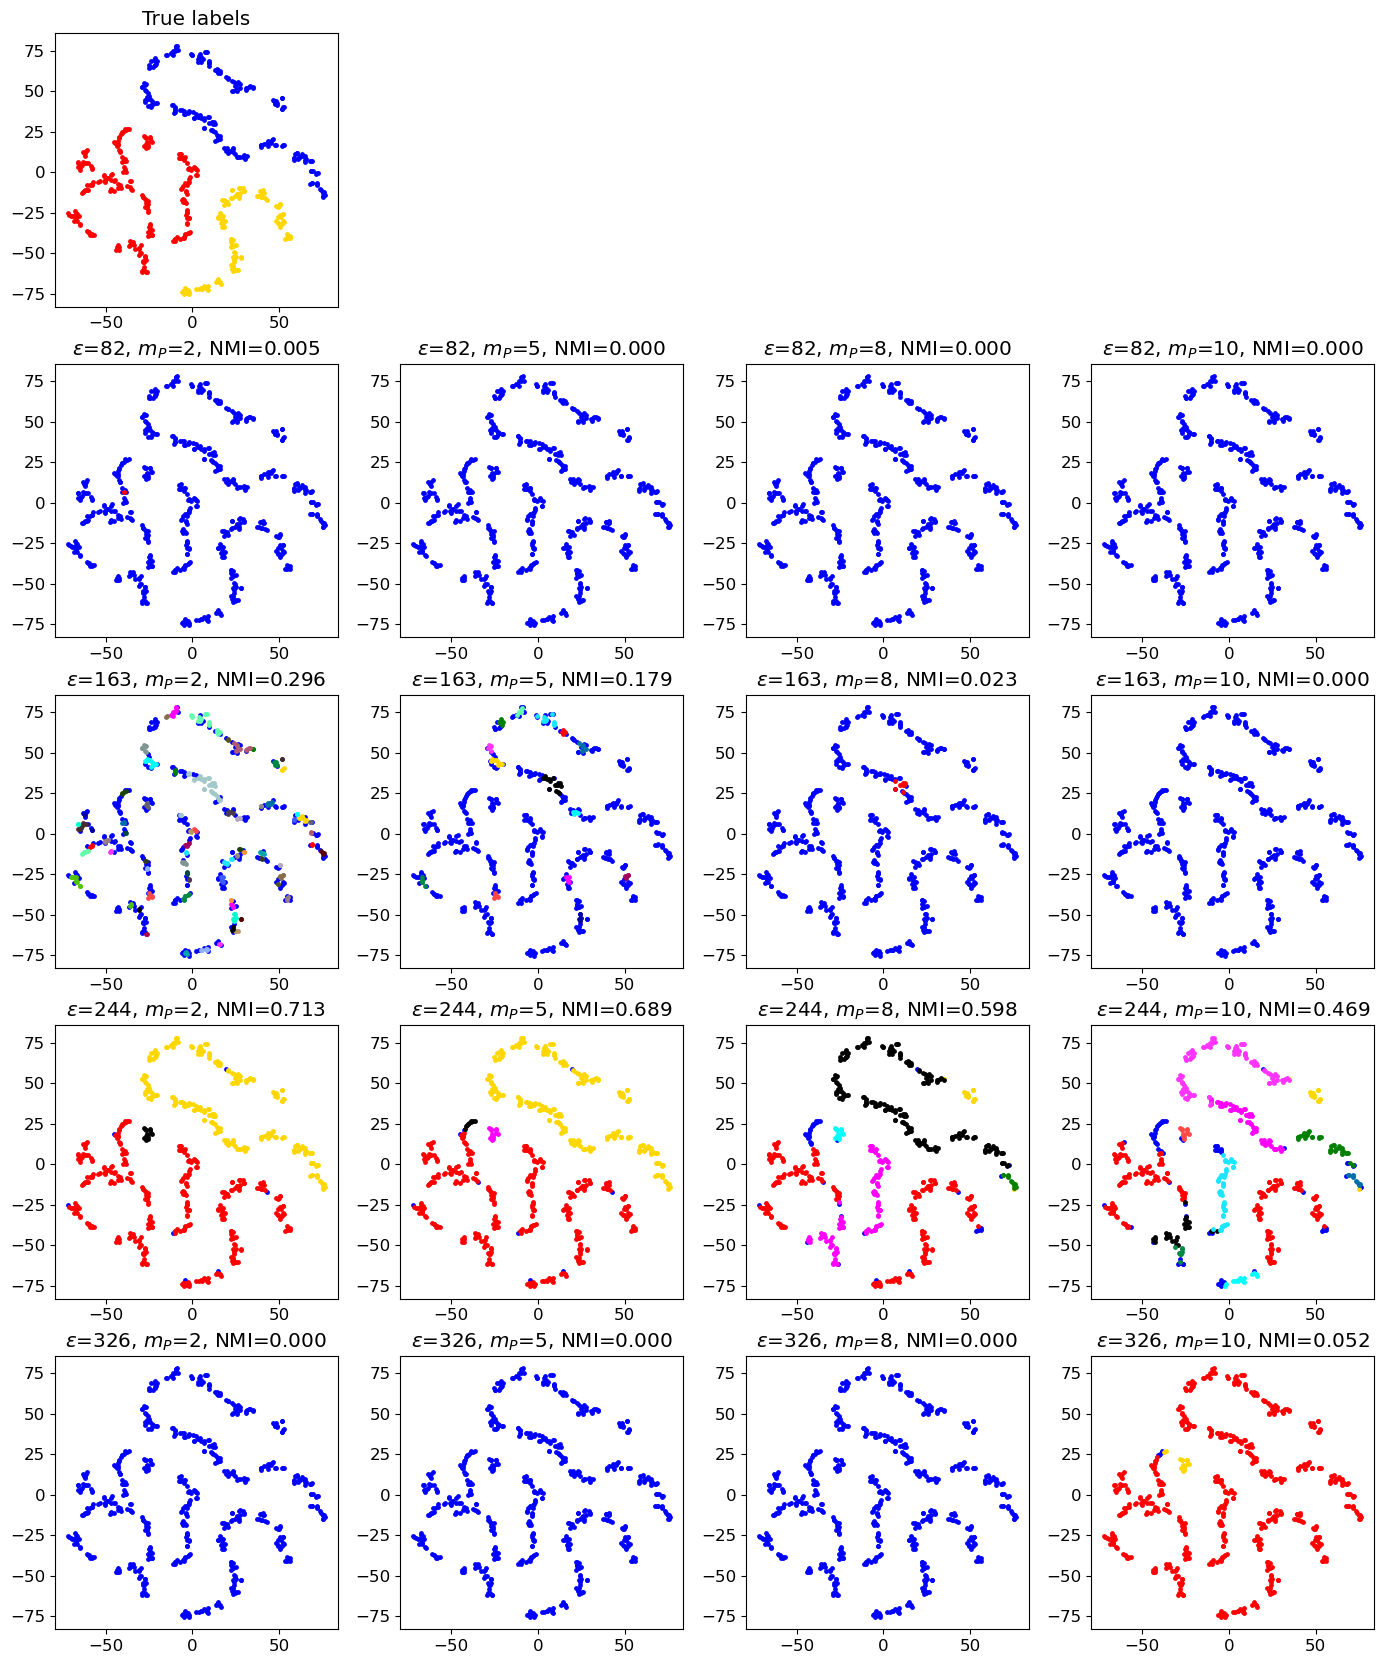

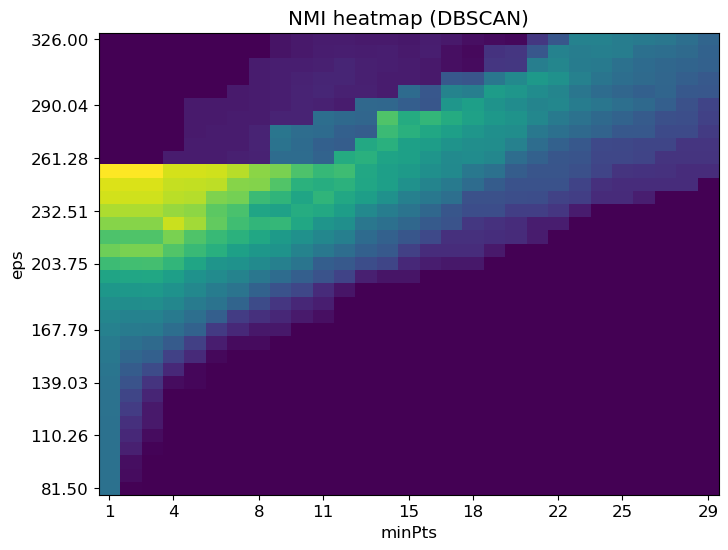

Best epsilon and minimum points:  254.08823529411765 1


In [17]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
cpalette = ["blue","red","gold","black","magenta","green","cyan","#1CE6FF", "#FF34FF", "#FF4A46","#008941", "#006FA6", "#A30059", "#0000A6", "#63FFAC","#B79762", "#004D43", "#8FB0FF", "#997D87","#5A0007", "#809693","#1B4400", "#4FC601", "#3B5DFF", "#4A3B53","#886F4C","#34362D", "#B4A8BD", "#00A6AA", "#452C2C","#636375", "#A3C8C9", "#FF913F", "#938A81","#575329", "#00FECF", "#B05B6F"]
from collections import OrderedDict
ms = 6

def clustering(y):
    # Finds position of labels and returns a dictionary of cluster labels to data indices.
    yu = np.sort(np.unique(y))
    clustering = OrderedDict()
    for ye in yu:
        clustering[ye] = np.where(y == ye)[0]
    return clustering

def entropy(c, n_sample):
    # Measures the shannon entropy of a cluster
    # c is a dictinary of cluster labels to data indices 
    # n_sample is the total number of data points
    h = 0.
    for kc in c.keys():
        p=len(c[kc])/n_sample
        h+=p*np.log(p)
    h*=-1.
    return h

# Normalized mutual information function
# Note that this deals with the label permutation problem
def NMI(y_true, y_pred):
    """ Computes normalized mutual information: where y_true and y_pred are both clustering assignments
    """
    w = clustering(y_true) # clustering of the true labels
    c = clustering(y_pred) # clustering of the predicted labels
    n_sample = len(y_true)

    Iwc = 0. # mutual information between w and c
    for kw in w.keys():
        for kc in c.keys():
            w_intersect_c=len(set(w[kw]).intersection(set(c[kc]))) # number of data points in the intersection of cluster kw and kc
            if w_intersect_c > 0:
                Iwc += w_intersect_c*np.log(n_sample*w_intersect_c/(len(w[kw])*len(c[kc]))) # mutual information contribution of the intersection of cluster kw and kc
    Iwc/=n_sample
    Hc = entropy(c,n_sample) # entropy of the predicted clustering
    Hw = entropy(w,n_sample) # entropy of the true clustering

    return 2*Iwc/(Hc+Hw)

def plotting_ax(X, y, ax):
    # plotting function
    for i, yu in enumerate(np.unique(y)):
        pos = (y == yu)
        ax.scatter(X[pos,0], X[pos,1],c=cpalette[i%len(cpalette)],s=ms)

# DBSCAN has a few parameters, let's sweep over a few parameters and see what happens
np.random.seed(12345)
n_true_center=3 
#X, ytrue = make_blobs(10000, 2, n_true_center) # Generating random gaussian mixture
X2D = X_all[2] # best(?) visualization of the data in 2D, obtained by t-SNE with perplexity=8
X = data
y_true = y

#eps_range = [0.01,0.1,0.5,1.0,10.]
if mean_min_dist<10:
    r=mean_min_dist # mean minimum distance between nn points
else:
    r = int(mean_min_dist)
eps_range = [r/2,r,1.5*r,2*r] # range of eps values to try

min_sample_range = [2,5,8,10] 
DIMY=len(eps_range) 
DIMX=len(min_sample_range)
fig, ax = plt.subplots(DIMY+1,DIMX,figsize=(14,16.8))

i,j=0,0
nmi=1
plotting_ax(X2D,y,ax[i,j])
ax[i,j].set_title('True labels')

nmi_matrix = np.zeros((len(eps_range), len(min_sample_range)))
for j in range(1,DIMX): fig.delaxes(ax[i,j])
    
for i, eps in enumerate(eps_range):
    for j, min_samples in enumerate(min_sample_range):
        model = DBSCAN(eps=eps, min_samples=min_samples)
        model.fit(X)
        y_hat = model.labels_ # predicted labels
        plotting_ax(X2D,y_hat,ax[i+1,j])
        nmi=NMI(y_hat, y_true)
        ax[i+1,j].set_title(r'$\epsilon$=%.0f, $m_P$=%i, NMI=%.3f'%(eps,min_samples,nmi))

eps_range = np.linspace(0.5*r, 2*r, 35)
min_sample_range = np.arange(1,30)
nmi_matrix = np.zeros((len(eps_range), len(min_sample_range)))
for i, eps in enumerate(eps_range):
    for j, min_samples in enumerate(min_sample_range):
        model = DBSCAN(eps=eps, min_samples=min_samples)
        model.fit(X)
        y_hat = model.labels_ # predicted labels
        nmi = NMI(y_hat, y_true)
        nmi_matrix[i, j] = nmi
    
plt.tight_layout(h_pad=0.5)
plt.show()
plt.figure(figsize=(8,6))

plt.imshow(nmi_matrix, origin='lower', aspect='auto')

plt.colorbar

plt.xticks(range(len(min_sample_range)), min_sample_range)
plt.yticks(range(len(eps_range)), [f"{e:.2f}" for e in eps_range])

plt.xlabel("minPts")
plt.ylabel("eps")
plt.title("NMI heatmap (DBSCAN)")
num_xticks = 9
num_yticks = 9

xtick_pos = np.linspace(0, len(min_sample_range)-1, num_xticks, dtype=int)
ytick_pos = np.linspace(0, len(eps_range)-1, num_yticks, dtype=int)

plt.xticks(xtick_pos, [min_sample_range[i] for i in xtick_pos])
plt.yticks(ytick_pos, [f"{eps_range[i]:.2f}" for i in ytick_pos])

plt.show()

max_idx = np.argmax(nmi_matrix)
max_pos = np.unravel_index(max_idx, nmi_matrix.shape)
eps_opt = eps_range[max_pos[0]]
min_sample_opt = min_sample_range[max_pos[1]]
print("Best epsilon and minimum points: ", eps_opt, min_sample_opt)

## Correlation from heatmap
There 's a positive correlation between epsilon and the minimum of points, we can notice that from a certain value of epsilon the value of the nmi drops significatly. 

## 2. Understanding the 12-dimensional data

Explained variance ratio with n=2 dimensions 0.8697080866745368


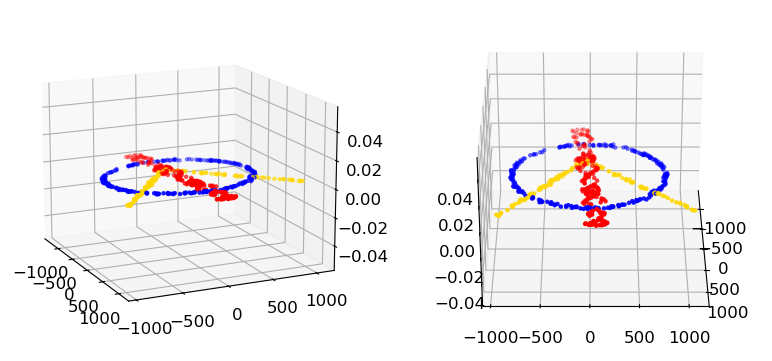

Explained variance ratio with n=3 dimensions 0.9628284852121717


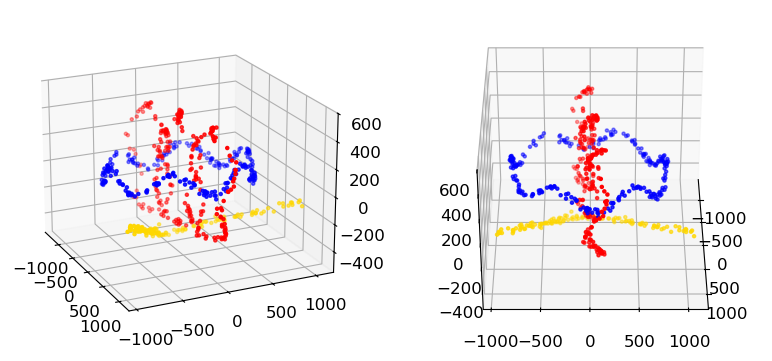

In [18]:
mycmap = ListedColormap(["blue","red","gold" ])

pca = PCA(n_components=2)

x_pca = pca.fit_transform(x)
print("Explained variance ratio with n=2 dimensions", np.sum(pca.explained_variance_ratio_))

fig = plt.figure(figsize=(15, 5))
for i in range(2):
    ax = fig.add_subplot(1,3,i+1,projection='3d')
    ax.scatter(x_pca[:,0], x_pca[:,1], s=5, c=y, depthshade=True, cmap=mycmap)
    ax.view_init(15+15*i, 25*(i-1))
    
plt.show()

pca_ = PCA(n_components=3)

x_pca_ = pca_.fit_transform(x)
print("Explained variance ratio with n=3 dimensions", np.sum(pca_.explained_variance_ratio_))

fig_ = plt.figure(figsize=(15, 5))
for i in range(2):
    ax = fig_.add_subplot(1,3,i+1,projection='3d')
    ax.scatter(x_pca_[:,0], x_pca_[:,1], x_pca_[:,2], s=5, c=y, depthshade=True, cmap=mycmap)
    ax.view_init(20+15*i, 25*(i-1))
    
plt.draw()
plt.show()

Principal component analysis (PCA) helps understand the data structure, as keeping only the 3 principal components we can explain around 96% of the dataset's total variability. 

## 3. Confrontation with k-means

C:\Users\fardi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


NMI k-means: 0.125
NMI DBSCAN: 0.764


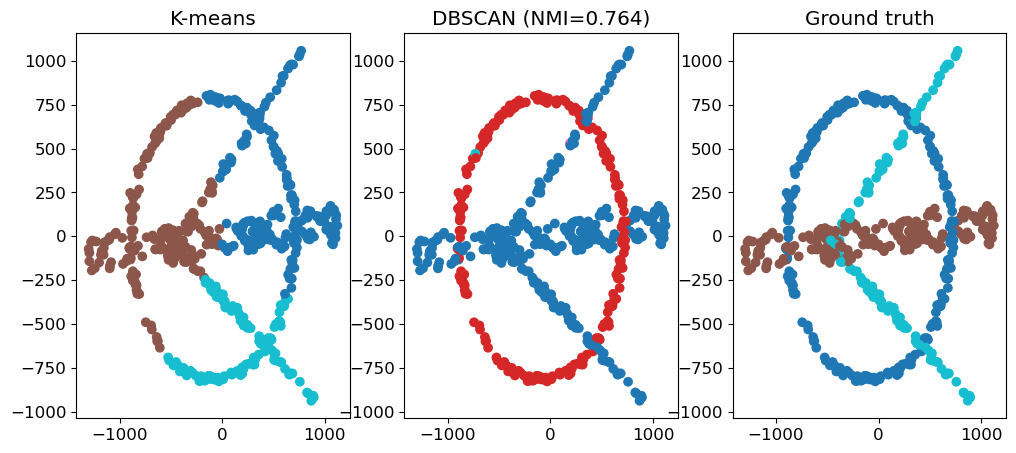

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score

# scaled data
x_scaled = StandardScaler().fit_transform(x)

# kmeans valuation
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(x_scaled)

nmi_km = normalized_mutual_info_score(y, labels_km)
print(f"NMI k-means: {nmi_km:.3f}")

# dbscan optimized
labels_dbscan = DBSCAN(eps=eps_opt, min_samples=min_sample_opt).fit_predict(X)
nmi_dbscan = normalized_mutual_info_score(y, labels_dbscan)
print(f"NMI DBSCAN: {nmi_dbscan:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(12,5))
plt.title("Comparison with 2 dimnesions")
axes[0].scatter(x_pca[:,0], x_pca[:,1], c=labels_km, cmap='tab10')
axes[0].set_title("K-means")
axes[1].scatter(x_pca[:,0], x_pca[:,1], c=labels_dbscan, cmap='tab10')
axes[1].set_title(f"DBSCAN (NMI={nmi_dbscan:.3f})")
axes[2].scatter(x_pca[:,0], x_pca[:,1], c=y, cmap='tab10')
axes[2].set_title("Ground truth")
plt.show()

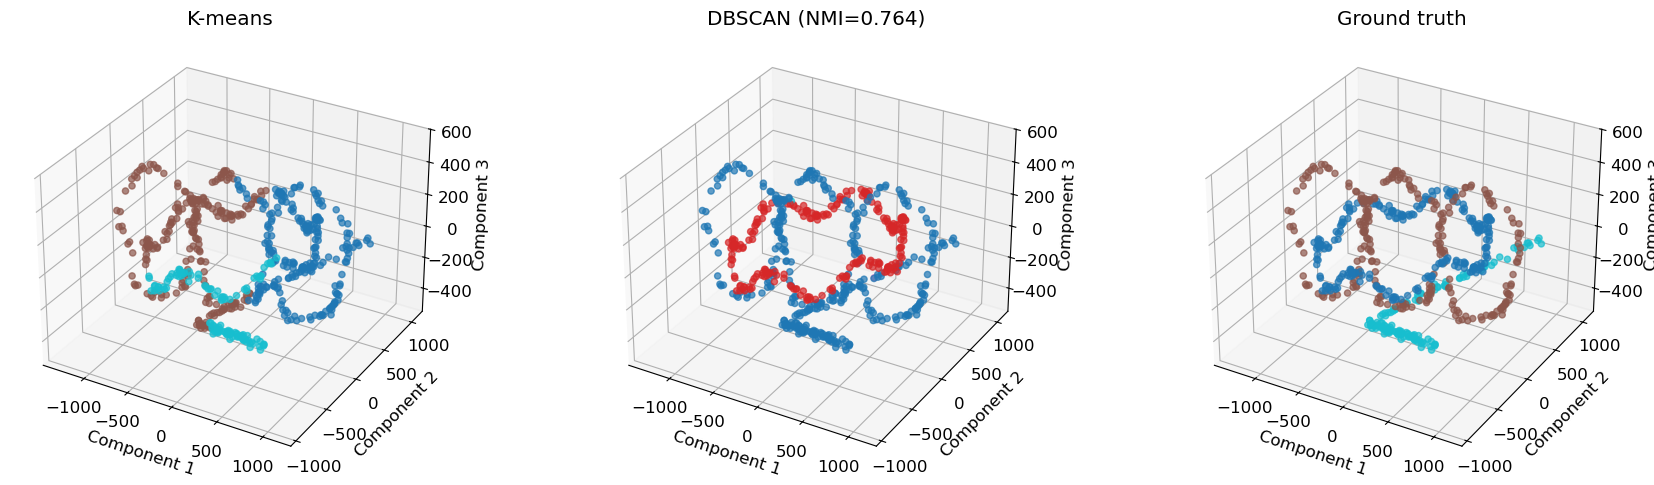

In [20]:
fig = plt.figure(figsize=(18, 5))

titles = ["K-means", f"DBSCAN (NMI={nmi_dbscan:.3f})", "Ground truth"]
labels_list = [labels_km, labels_dbscan, y]

for i, (title, labels) in enumerate(zip(titles, labels_list)):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    ax.scatter(x_pca_[:,0], x_pca_[:,1], x_pca_[:,2],
               c=labels, cmap='tab10', s=20, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.set_zlabel("Component 3")

plt.tight_layout()
plt.show()

The comparison between k-means and the ground truth is bad, since the points are grouped in an almost spherical cluster, and `NMI_k-means = 0.125`, while DBSCAN has a pretty good `NMI_DBSCAN = 0.764`.

This result could be a consequence of high and different variances for each cluster. In fact, k-means clustering works on the assumption that all clusters have the same variance, which is not true for this case. 

## 4. Compare with hierarchical clustering

### Visualizing clusters with dendograms and printing NMI for each method used

Maximum number of cluster expected: 3
----------------------------------------------------
NMI scores by linkage method:
      DBSCAN:  0.7637
     k-means:  0.1251
      single:  0.0076
    complete:  0.0509
     average:  0.1639
    weighted:  0.0651
    centroid:  0.1515
      median:  0.1318
        ward:  0.1662


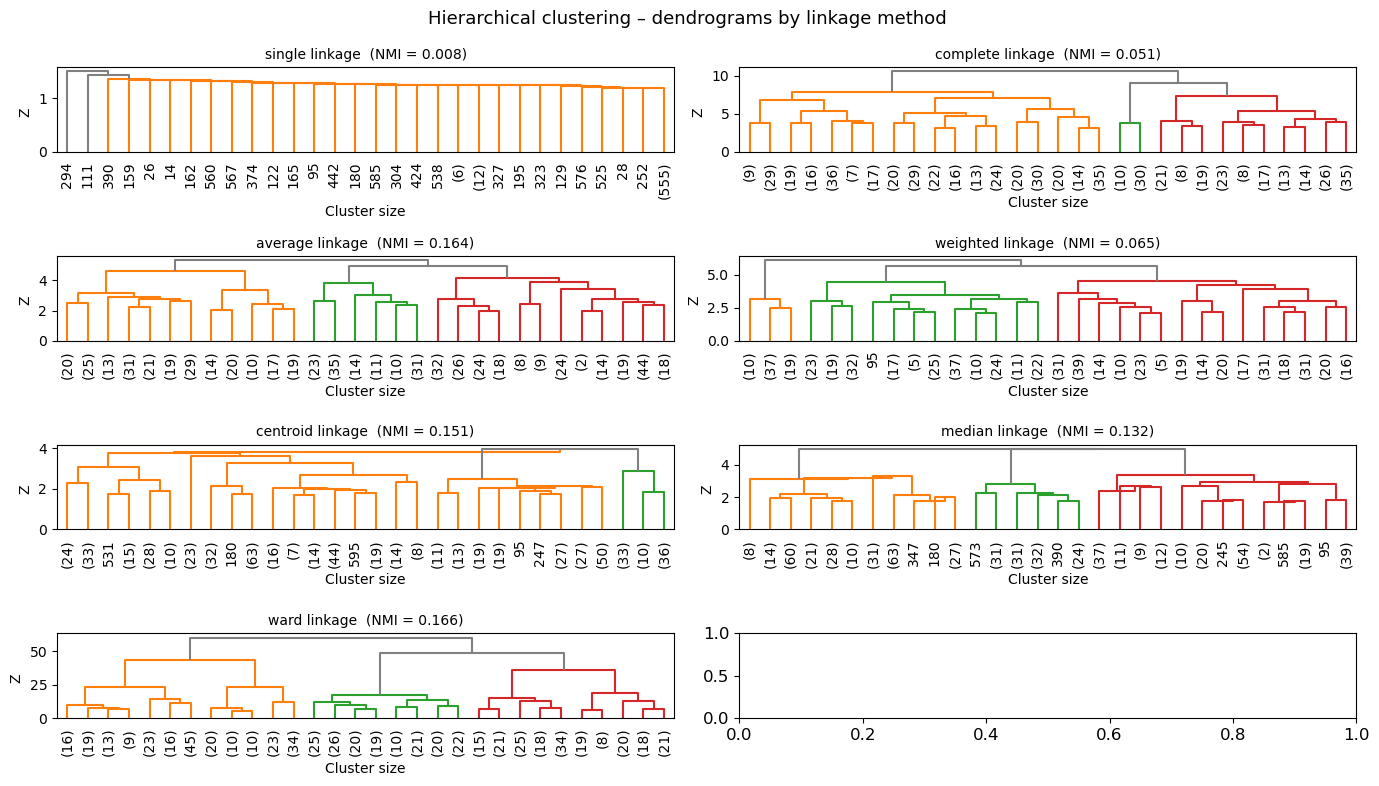

In [21]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

n_true_clusters = len(np.unique(y_true)) 
print(f"Maximum number of cluster expected: {n_true_clusters}\n----------------------------------------------------")

#comparing all the linkage method avaible for the linkage class
linkage_methods = ["single", "complete", "average", "weighted","centroid","median","ward"]
#definining the nmi dict for collecting the scores 
nmi_scores = {}

nmi_scores["DBSCAN"] = nmi_dbscan
nmi_scores["k-means"] = nmi_km


for method in linkage_methods:
    #the linkage matrix contains all the possible hierarchical clusters bottom-up
    linkage_matrix = linkage(x_scaled, method=method)
    #fcluster allow us to decide where to cut the linkage matrix:
    #we used max-clust meaning that we just show the dendogram from 1 to 3 (the number of real ones) clusters
    labels = fcluster(linkage_matrix, t=n_true_clusters, criterion="maxclust")
    nmi_scores[method] = normalized_mutual_info_score(y_true, labels)

print("NMI scores by linkage method:")
for m, s in nmi_scores.items():
    print(f"  {m:>10s}:  {s:.4f}")

#plotting the dendograms
fig, axes = plt.subplots(4, 2, figsize=(14, 8))
fig.suptitle("Hierarchical clustering – dendrograms by linkage method", fontsize=13)

for ax, method in zip(axes.flat, linkage_methods):
    linkage_matrix = linkage(x_scaled, method=method)
    threshold = (linkage_matrix[-2, 2] + linkage_matrix[-3, 2]) / 2 
    nmi = nmi_scores[method]

    dendrogram(linkage_matrix, ax=ax, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=7,
               color_threshold= threshold, above_threshold_color="grey")
    ax.set_title(f"{method} linkage  (NMI = {nmi:.3f})", fontsize=10)
    ax.set_xlabel("Cluster size", fontsize=10)
    ax.set_ylabel("Z ", fontsize=10)
    ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()

plt.show()

### Bar plot: NMI vs Method used

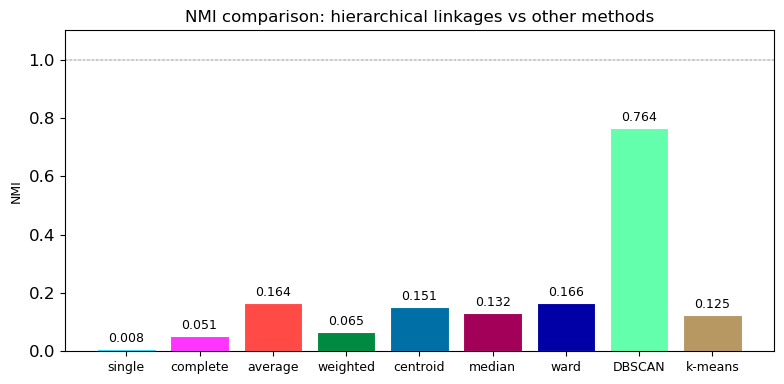

In [22]:
# bar chart for comparing the methods
fig, ax = plt.subplots(figsize=(8, 4))

bar_labels  = list(linkage_methods)
bar_values  = [nmi_scores[m] for m in linkage_methods]
bar_colors  = ["#1CE6FF", "#FF34FF", "#FF4A46","#008941", "#006FA6", "#A30059", "#0000A6", "#63FFAC","#B79762", "#004D43", "#8FB0FF", "#997D87","#5A0007", "#809693","#1B4400", "#4FC601", "#3B5DFF", "#4A3B53","#886F4C","#34362D", "#B4A8BD", "#00A6AA", "#452C2C","#636375", "#A3C8C9", "#FF913F", "#938A81","#575329", "#00FECF", "#B05B6F"]

#adding the scores for DBSCAN and k-means
bar_labels.append("DBSCAN")
bar_values.append(nmi_dbscan)
bar_labels.append("k-means")
bar_values.append(nmi_km)

bars = ax.bar(bar_labels, bar_values, color=bar_colors, edgecolor="white", linewidth=0.8)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_ylabel("NMI", fontsize=9)
ax.set_title("NMI comparison: hierarchical linkages vs other methods", fontsize=12)
ax.axhline(1.0, color="#000000", linewidth=0.3, linestyle="-.")
ax.tick_params(axis="x", labelsize=9)

plt.tight_layout()
plt.show()

We observe that DBSCAN is by far the best model.

### How does the metric influence the NMI
We now study how the metric influences the results. We do not include all available metrics because some of them cause issues when creating the linkage matrix (e.g. `fcluster` cannot accept a linkage matrix created with the cosine metric).

In [23]:
metrics = ["euclidean", "cityblock", "braycurtis", "braycurtis", "canberra", "chebyshev",  "minkowski", "sqeuclidean"]
nmi_scores_metric = {}

for method in linkage_methods:
    if not (method == "centroid" or method == "median" or method == "ward"):
        print(f"\n------------------------\nNMI scores by metric using method: {method.capitalize()}")
        tmp = {}
        for m in metrics:
            linkage_matrix = linkage(x_scaled, method=method, metric=m)
            labels = fcluster(linkage_matrix, t=n_true_clusters, criterion="maxclust")
            tmp[m] = normalized_mutual_info_score(y_true, labels)
        nmi_scores_metric[method] = tmp
        for m, s in tmp.items():
            print(f"  {m:>16s}:  {s:.4f}")


------------------------
NMI scores by metric using method: Single
         euclidean:  0.0076
         cityblock:  0.0076
        braycurtis:  0.0055
          canberra:  0.0081
         chebyshev:  0.0057
         minkowski:  0.0076
       sqeuclidean:  0.0076

------------------------
NMI scores by metric using method: Complete
         euclidean:  0.0509
         cityblock:  0.0349
        braycurtis:  0.0087
          canberra:  0.0000
         chebyshev:  0.1438
         minkowski:  0.0509
       sqeuclidean:  0.0509

------------------------
NMI scores by metric using method: Average
         euclidean:  0.1639
         cityblock:  0.1284
        braycurtis:  0.1596
          canberra:  0.1165
         chebyshev:  0.1213
         minkowski:  0.1639
       sqeuclidean:  0.1611

------------------------
NMI scores by metric using method: Weighted
         euclidean:  0.0651
         cityblock:  0.1006
        braycurtis:  0.1855
          canberra:  0.1577
         chebyshev:  0.

To gain a deeper understanding of how the metric influences the NMI, we normalize it using the formula:
$$NMI_{normalized}=\frac{NMI_{forEachMethod} - \min(NMI_{forEachMethod})}{\max(NMI_{forEachMethod}) - \min(NMI_{forEachMethod})}$$
We do this because some methods perform much better than others, and therefore have a greater impact on the mean we are studying.

Shape: (4, 8)
[0.0081494  0.14375265 0.16385417 0.18550356]


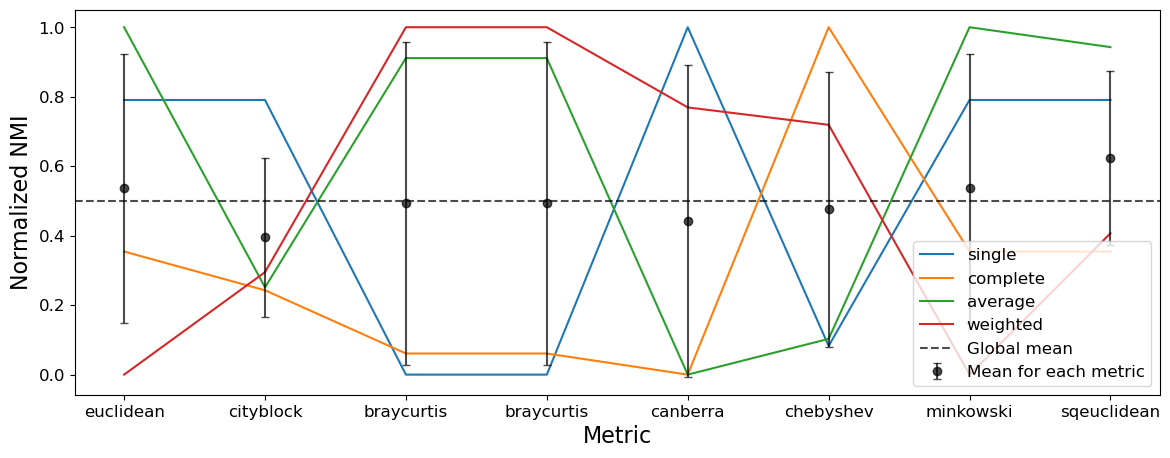

(8,)


In [24]:
methods_list = list(nmi_scores_metric.keys())
metrics_list = metrics 

arr = np.array([[nmi_scores_metric[method][m] for m in metrics_list]
                for method in methods_list])

print("Shape:", arr.shape)

maximums = np.max(arr, axis=1)
minimums = np.min(arr, axis=1)
print(maximums)
arr-=minimums[:, np.newaxis]
arr/=(maximums - minimums)[:, np.newaxis] 
means = np.mean(arr, axis=0)
std = np.std(arr, axis=0)

fig, ax = plt.subplots(1, 1, figsize=(14, 5))

for i in range(arr.shape[0]):
    ax.plot(arr[i], label=methods_list[i])
ax.errorbar(range(len(means)), means,  yerr=std, fmt="ko",capsize=3, alpha=0.7, label="Mean for each metric")
ax.axhline(np.mean(means), linestyle="--", color="black", alpha=0.7, label="Global mean")
ax.set_xticks(range(len(metrics)), metrics)
ax.set_xlabel("Metric", fontsize=16)
ax.set_ylabel("Normalized NMI", fontsize=16)



plt.legend(loc='lower right')
plt.show()

print(means.shape)

As we can see, all the data agree with the overall mean within 1 sigma. We conclude that the metric does not significantly influence the NMI in general. Therefore, it is best to choose the most suitable metric for each specific method.

## 5. Visualize data

Manifold learning is an approach to non-linear dimensionality reduction.

In [36]:
from matplotlib import ticker

n_neighbors = [10, 15, 20, 25]  # neighborhood which is used to recover the locally linear structure
n_components = 2  # number of coordinates for the manifold

def add_2d_scatter(ax, points, points_color, title=None, n=None):
    x, y = points.T
    ax.scatter(x, y, c=points_color, s=50, alpha=0.8)
    if title!=None and n!=None:
        ax.set_title(title + " n=%d" % n, size=8)
    elif n!=None:
        ax.set_title("%d neighbors" % n, size=12)
    elif title!=None:
        ax.set_title(title, size=10)
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.NullFormatter())


### Locally linear embeddings (LLE)

Locally linear embedding can be thought of as a series of local Principal Component Analyses which are globally compared to find the best non-linear embedding.

In [26]:
standard_l = []
ltsa_l = []
hessian_l = []
mod_l = []

for i, n in enumerate(n_neighbors):
    params = {
        "n_neighbors": n,
        "n_components": n_components,
        "eigen_solver": "auto",
        "random_state": 0,
    }

    lle_standard = manifold.LocallyLinearEmbedding(method="standard", **params)
    x_standard = lle_standard.fit_transform(x)
    standard_l.append(x_standard)

    lle_ltsa = manifold.LocallyLinearEmbedding(method="ltsa", **params)
    x_ltsa = lle_ltsa.fit_transform(x)
    ltsa_l.append(x_ltsa)
    
    lle_hessian = manifold.LocallyLinearEmbedding(method="hessian", **params)
    x_hessian = lle_hessian.fit_transform(x)
    hessian_l.append(x_hessian)
    
    lle_mod = manifold.LocallyLinearEmbedding(method="modified", **params)
    x_mod = lle_mod.fit_transform(x)
    mod_l.append(x_mod)

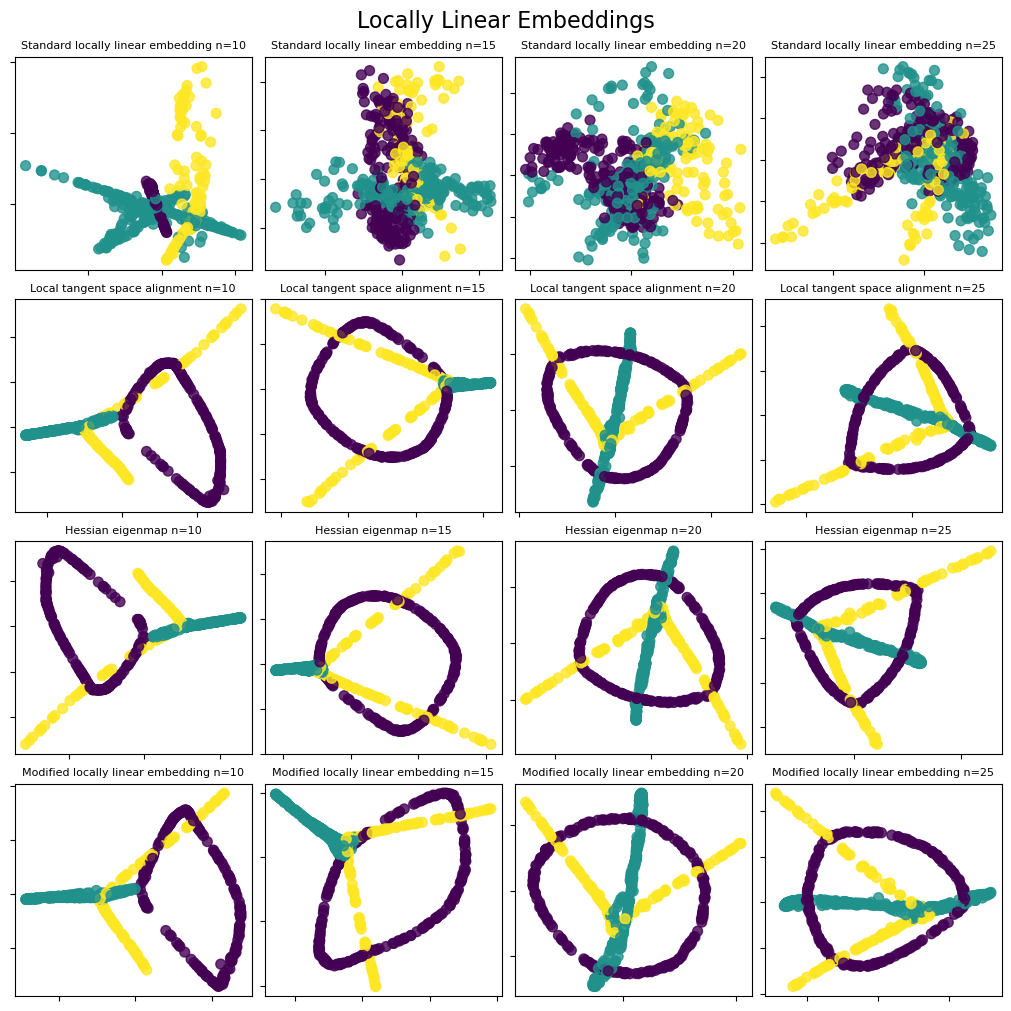

In [27]:
fig, axs = plt.subplots(
    nrows=4, ncols=4, figsize=(10, 10), facecolor="white", constrained_layout=True
)
fig.suptitle("Locally Linear Embeddings", size=16)

lle_methods = [
    ("Standard locally linear embedding", standard_l),
    ("Local tangent space alignment", ltsa_l),
    ("Hessian eigenmap", hessian_l),
    ("Modified locally linear embedding", mod_l),
]
for i, (name, points) in enumerate(lle_methods):
    for j, neigh in enumerate(n_neighbors):
        add_2d_scatter(axs[i, j], points[j], y, name, neigh)

plt.show()

### Isomap embedding

Isomap seeks a lower-dimensional embedding which maintains geodesic distances between points.

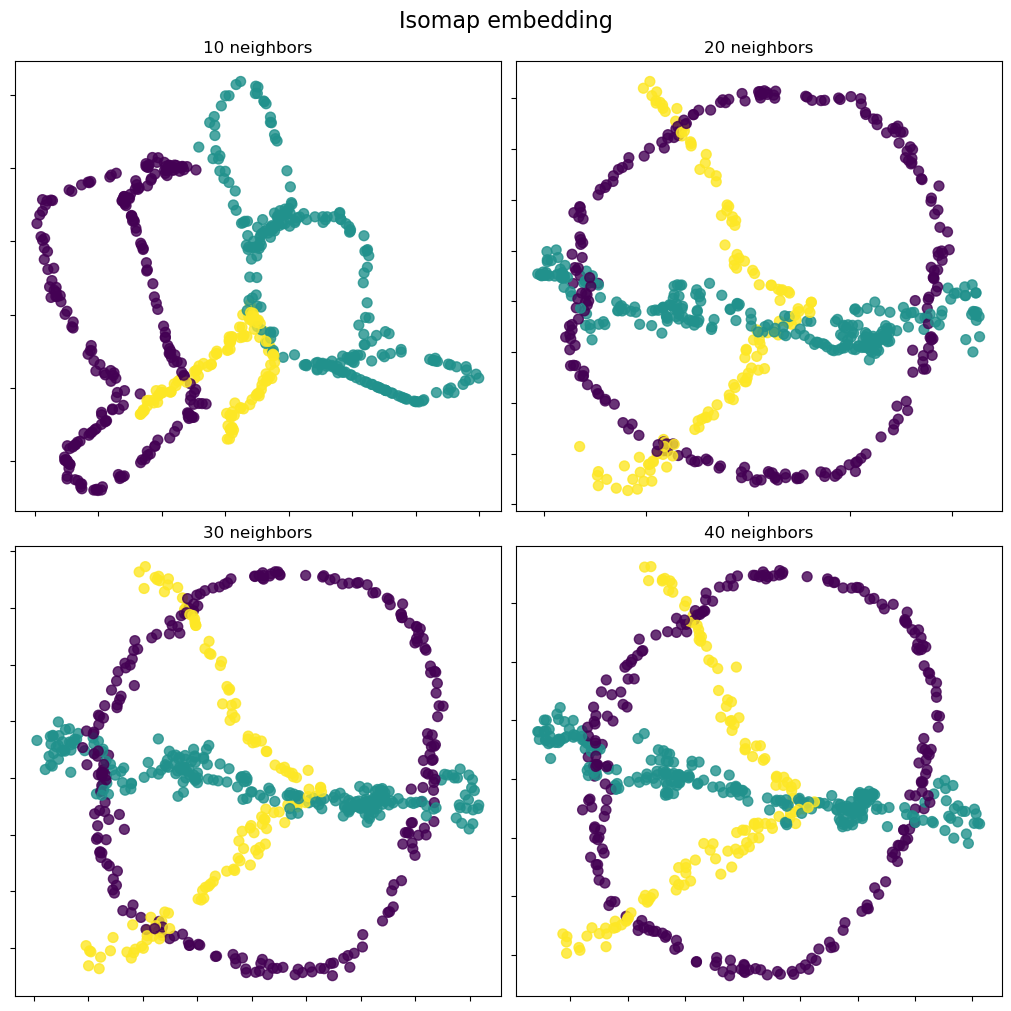

In [33]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10), facecolor="white", constrained_layout=True)
fig.suptitle("Isomap embedding", size=16)
ax_f = ax.flatten()

for i, n in enumerate(n_neighbors):
    isomap = manifold.Isomap(n_neighbors=n, n_components=n_components, p=1)
    x_isomap = isomap.fit_transform(x)
    add_2d_scatter(ax_f[i], x_isomap, y, title=None, n=n)
plt.show()

### Multidimensional scaling

Multidimensional scaling (MDS) seeks a low-dimensional representation of the data in which the distances respect well the distances in the original high-dimensional space.

In [29]:
md_scaling = manifold.MDS(
    n_components=n_components,
    max_iter=50,
    n_init=1,
    random_state=0,
    init="classical_mds",
    normalized_stress=False,
)
x_scaling_metric = md_scaling.fit_transform(x)

md_scaling_nonmetric = manifold.MDS(
    n_components=n_components,
    max_iter=50,
    n_init=1,
    random_state=0,
    normalized_stress=False,
    metric_mds=False,
    init="classical_mds",
)
x_scaling_nonmetric = md_scaling_nonmetric.fit_transform(x)

md_scaling_classical = manifold.ClassicalMDS(n_components=n_components)
x_scaling_classical = md_scaling_classical.fit_transform(x)

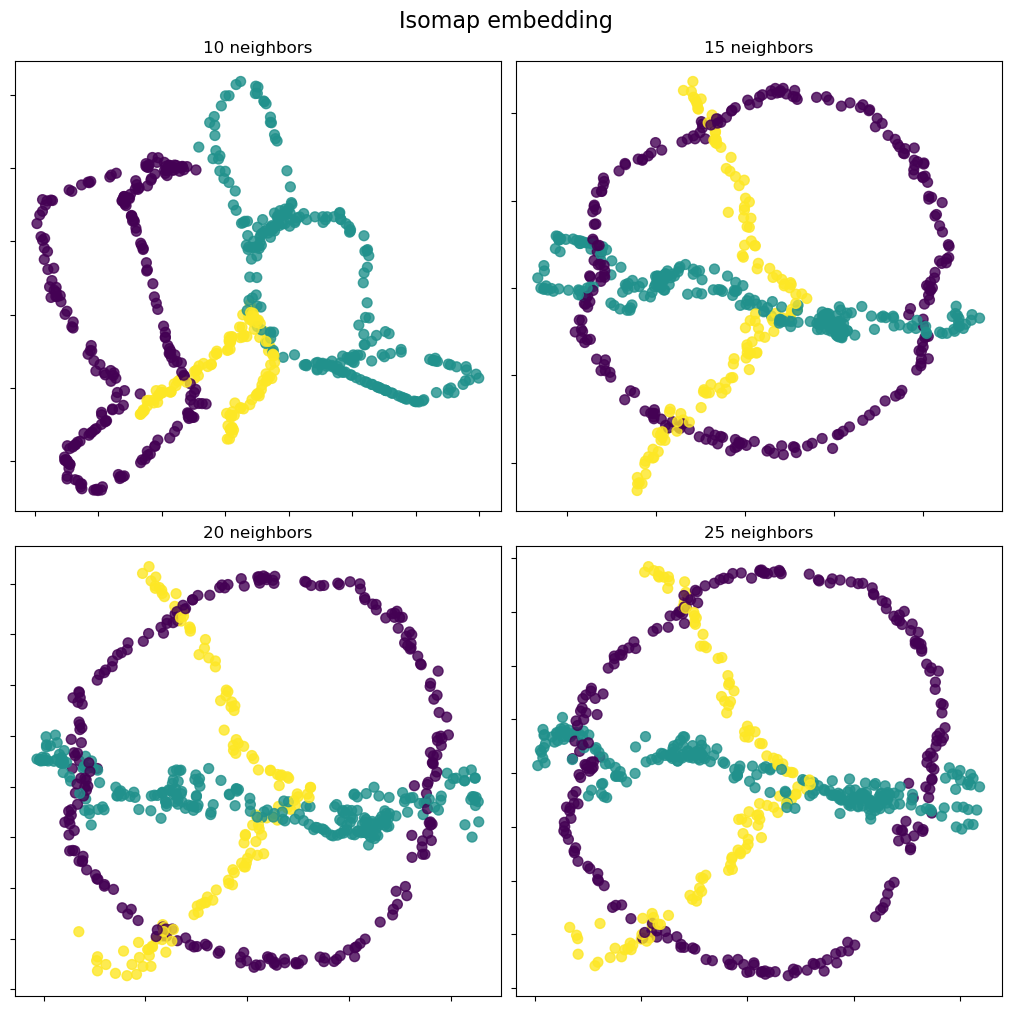

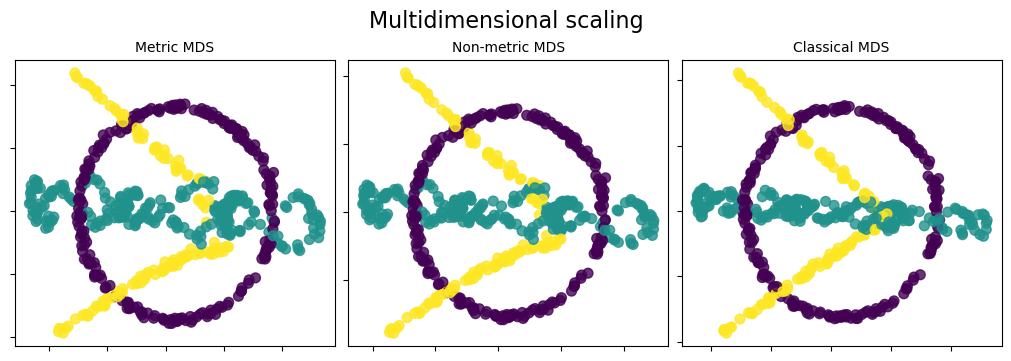

In [30]:
fig, axs = plt.subplots(
    nrows=1, ncols=3, figsize=(10, 3.5), facecolor="white", constrained_layout=True
)
fig.suptitle("Multidimensional scaling", size=16)

mds_methods = [
    ("Metric MDS", x_scaling_metric),
    ("Non-metric MDS", x_scaling_nonmetric),
    ("Classical MDS", x_scaling_classical),
]
for ax, method in zip(axs.flat, mds_methods):
    name, points = method
    add_2d_scatter(ax, points, y, name)

plt.show()

### Spectral embedding

It uses Laplacian Eigenmaps ehich finds a low dimensional representation of the data using a spectral decomposition of the graph Laplacian.

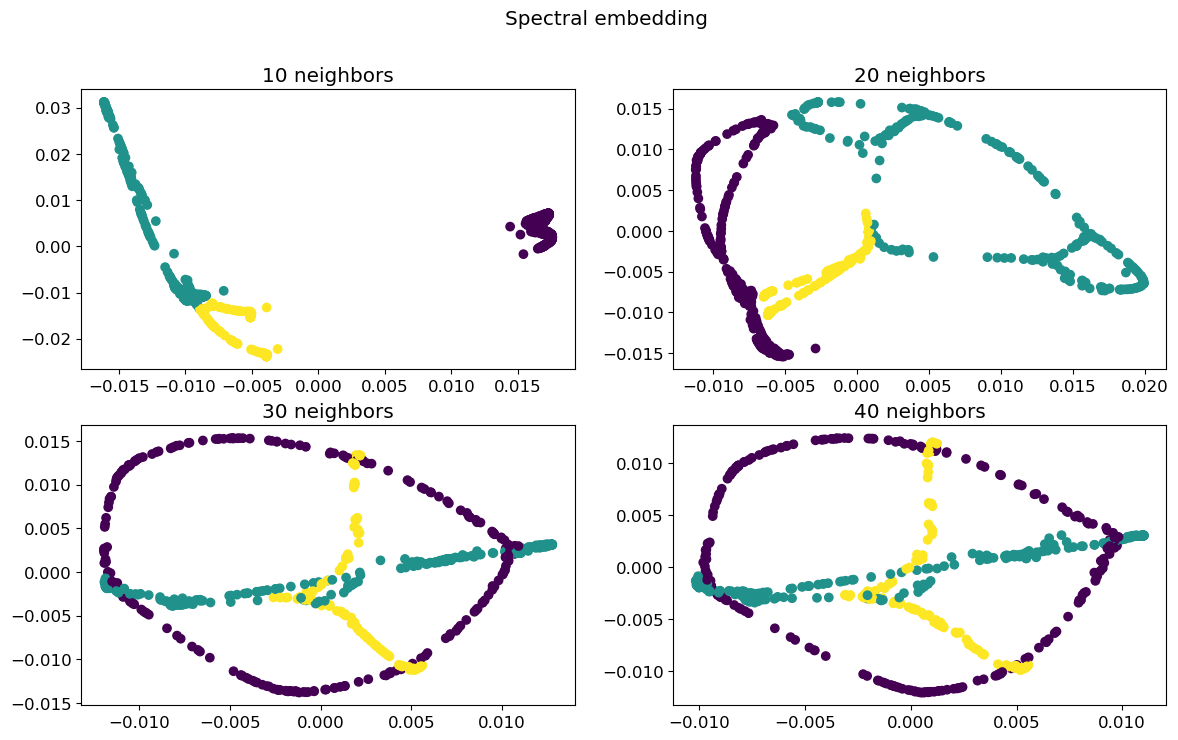

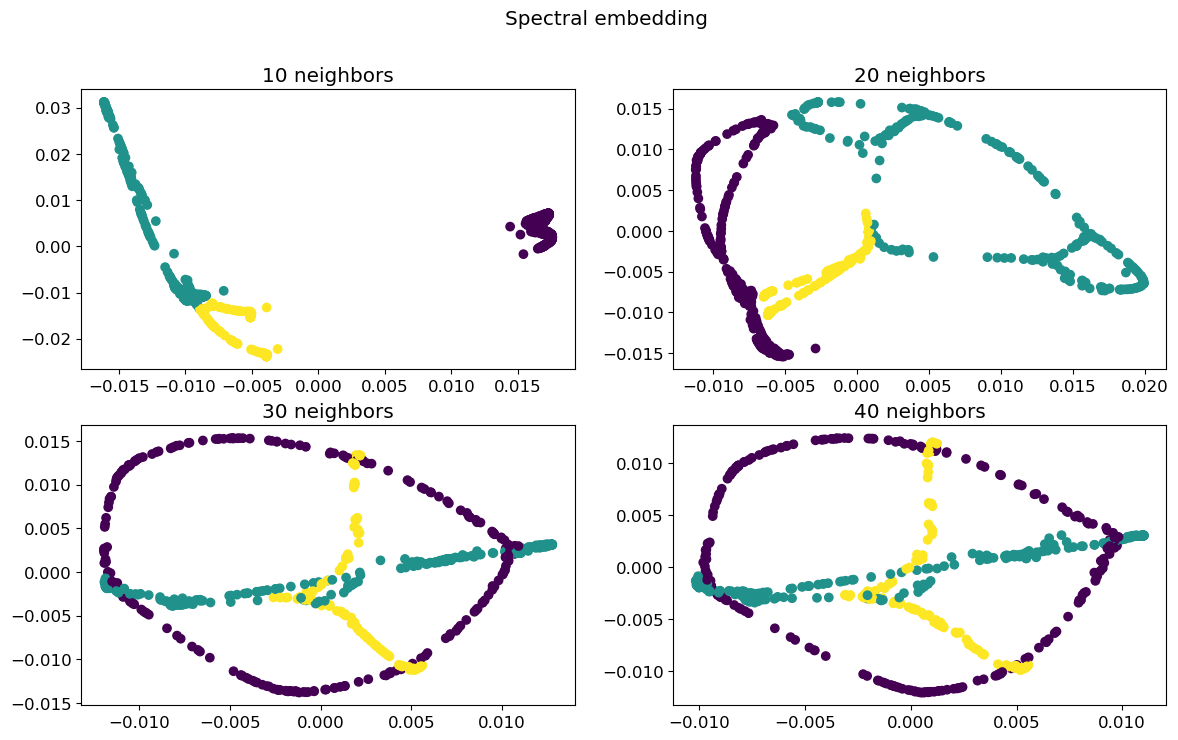

In [32]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14,8))
fig.suptitle("Spectral embedding")
axs_f = axs.flat

n_neighbors = [10, 20, 30, 40]

for i, n in enumerate(n_neighbors):
    spectral = manifold.SpectralEmbedding(
    n_components=n_components, n_neighbors=n, random_state=42
    )
    x_spectral = spectral.fit_transform(x)
    axs_f[i].scatter(x_spectral[:,0], x_spectral[:,1], c=y)
    axs_f[i].set_title("%d neighbors" % n)
plt.show()